# Iris Classification


## Objective
The goal of this project is to classify iris flowers into three species:
•⁠  ⁠Setosa
•⁠  ⁠Versicolor
•⁠  ⁠Virginica

based on features like:
•⁠  ⁠Sepal Length
•⁠  ⁠Sepal Width
•⁠  ⁠Petal Length
•⁠  ⁠Petal Width

## Dataset
We are using the famous Iris dataset available in sklearn.

## Steps Involved
1.⁠ ⁠Data Collection  
2.⁠ ⁠Import Libraries  
3.⁠ ⁠Data Cleaning & Preprocessing  
4.⁠ ⁠Exploratory Data Analysis (EDA)  
5.⁠ ⁠Feature Engineering & Selection  
6.⁠ ⁠Model Building  
7.⁠ ⁠Model Evaluation  
8.⁠ ⁠Testing the Model  

## Goal
Build a model that can accurately predict the species of an iris flower.

In [1]:
# Step 1: Import required Libraries

import pandas as pd              # For data handling

import numpy as np               # For numerical operations

import matplotlib.pyplot as plt  # For plotting
import seaborn as sns            # For visualization

from sklearn. model_selection import train_test_split  # For splitting dataset
from sklearn.preprocessing import StandardScaler       # For feature scaling


from sklearn. linear_model import LogisticRegression   # ML algorithm

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix # Evaluation

In [5]:
df = sns.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Data Cleaning & Preprocessing

•⁠  ⁠Check missing values  
•⁠  ⁠Check data types  
•⁠  ⁠No major cleaning required (dataset is clean)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [4]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [5]:
df.shape

(150, 5)

In [6]:
df.describe

<bound method NDFrame.describe of      sepal_length  sepal_width  petal_length  petal_width    species
0             5.1          3.5           1.4          0.2     setosa
1             4.9          3.0           1.4          0.2     setosa
2             4.7          3.2           1.3          0.2     setosa
3             4.6          3.1           1.5          0.2     setosa
4             5.0          3.6           1.4          0.2     setosa
..            ...          ...           ...          ...        ...
145           6.7          3.0           5.2          2.3  virginica
146           6.3          2.5           5.0          1.9  virginica
147           6.5          3.0           5.2          2.0  virginica
148           6.2          3.4           5.4          2.3  virginica
149           5.9          3.0           5.1          1.8  virginica

[150 rows x 5 columns]>

In [7]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
145    False
146    False
147    False
148    False
149    False
Length: 150, dtype: bool

In [8]:
print(df.duplicated().sum())

1


In [9]:
df= df.drop_duplicates()

In [10]:
df.shape

(149, 5)

In [11]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

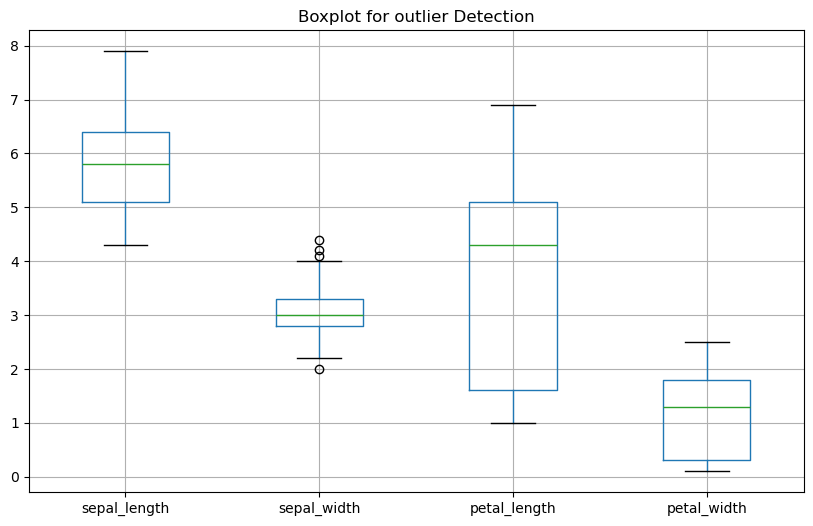

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
df.drop("species", axis=1).boxplot()
plt.title("Boxplot for outlier Detection")
plt.show()

In [13]:
Q1 = df["sepal_width"].quantile(0.25)
Q3 = df["sepal_width"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [14]:
print("lower bound:", lower)
print("upper bound:", upper)

lower bound: 2.05
upper bound: 4.05


In [15]:
outliers = df[(df["sepal_width"] < lower) | (df["sepal_width"] > upper)]
print ("otliers in sepal width:\n", outliers)

otliers in sepal width:
     sepal_length  sepal_width  petal_length  petal_width     species
15           5.7          4.4           1.5          0.4      setosa
32           5.2          4.1           1.5          0.1      setosa
33           5.5          4.2           1.4          0.2      setosa
60           5.0          2.0           3.5          1.0  versicolor


In [16]:
df_clean = df[(df["sepal_width"] >= lower) & (df["sepal_width"] <= upper)]
df_clean.shape

(145, 5)

In [17]:
df.select_dtypes(include=['number']).skew()

sepal_length    0.312826
sepal_width     0.307149
petal_length   -0.263101
petal_width    -0.090076
dtype: float64

##### All values are between -0.5 and +0.5
##### So data is approximately normally distributed
##### No major skewness problem

# Data visualisation

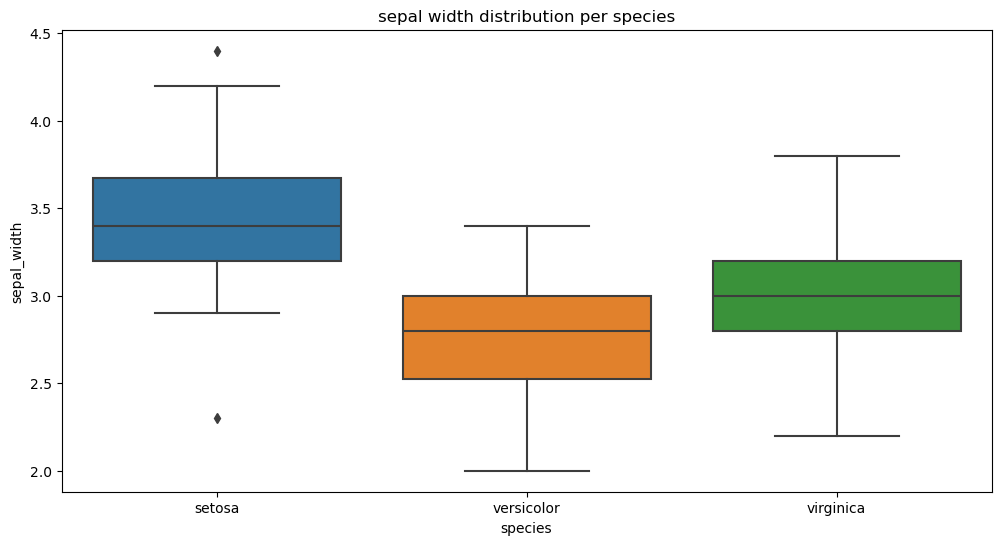

In [18]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='species', y='sepal_width')
plt.title("sepal width distribution per species")
plt.show()

## Insights from the boxplot

•⁠  ⁠*Setosa* has the widest and highest sepal width range.  
•⁠  ⁠*Versicolor* has the narrowest and lowest sepal width range.  
•⁠  ⁠*Virginica* has a sepal width range and median that are intermediate between the other two species.  

Overall, the boxplot shows that sepal width can be a distinguishing feature between the iris species, particularly between setosa and the other two.

<Axes: >

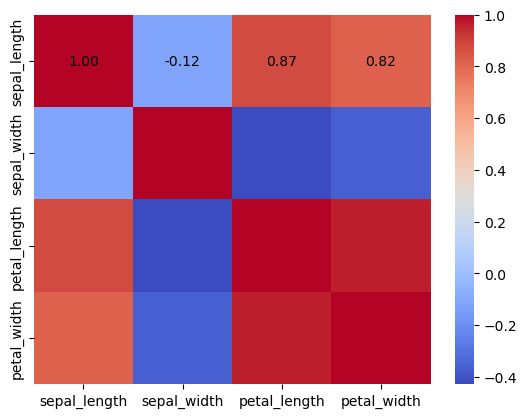

In [50]:
sns.heatmap(
    df.drop("species", axis=1).corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"color": "black"}  # or "white"
)

##  Insights

•⁠  ⁠*Petal Length & Petal Width* show a *very strong positive correlation (0.96)*  
  → As petal length increases, petal width also increases  
  → These are the *most important features*

•⁠  ⁠*Sepal Length* has a *good positive correlation* with:
  - Petal Length (0.87)
  - Petal Width (0.82)

•⁠  ⁠*Sepal Width* shows *negative correlation* with:
  - Petal Length (-0.43)
  - Petal Width (-0.36)

•⁠  ⁠*Sepal Length vs Sepal Width* has *very weak correlation (-0.12)*  
  → Indicates almost no relationship

### Conclusion (Heatmap)
•⁠  ⁠Petal features are *highly useful for prediction*
•⁠  ⁠Sepal width is *less significant*

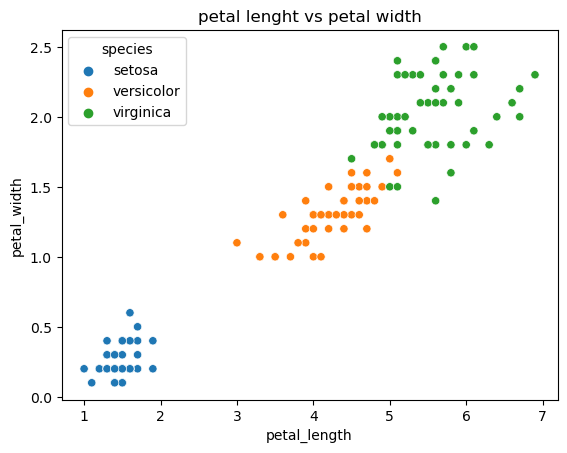

In [51]:
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species')
plt.title('petal lenght vs petal width')
plt.show()

### Insights (Petal Length vs Petal Width)

•⁠  ⁠The plot shows a *strong positive linear relationship*  
  → Confirms correlation from heatmap

### Class Distribution
•⁠  ⁠*Setosa*
  - Small petal length & width  
  - Clearly *separated from others*

•⁠  ⁠*Versicolor*
  - Medium petal size  
  - Slight *overlap with Virginica*

•⁠  ⁠*Virginica*
  - Large petal size  
  - More *spread out*

### Important Observation
•⁠  ⁠*Versicolor & Virginica overlap slightly*  
  → Harder to classify compared to Setosa


##  Final Conclusion

•⁠  ⁠Petal features (*petal_length, petal_width) are the **most important variables*
•⁠  ⁠*Setosa is easily separable*
•⁠  ⁠*Versicolor & Virginica require better models for classification*
•⁠  ⁠These features are highly useful for *machine learning models*

# Train Test Split

In [52]:
x = df.drop("species", axis=1)
y = df["species"]

In [53]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)


# Standardisation

In [54]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Modeling

In [55]:
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [56]:
y_pred = model.predict(x_test)

print("\nmodel Acuuracy:", accuracy_score(y_test, y_pred))

print("\nclassification report:\n", classification_report(y_test, y_pred))


model Acuuracy: 1.0

classification report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



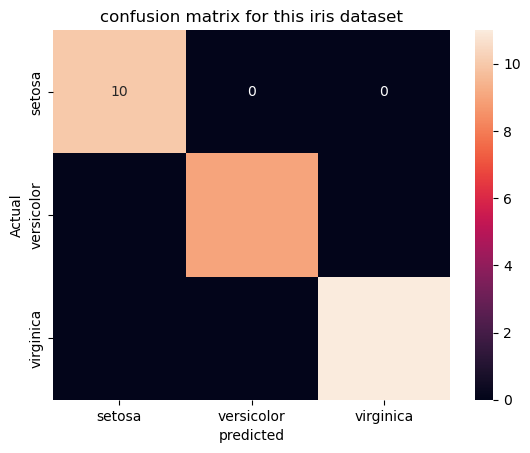

In [57]:
cm = confusion_matrix(y_test, y_pred)

import matplotlib.pyplot as plt
import seaborn as sns 

sns.heatmap(cm, annot=True,
            xticklabels=model.classes_,
            yticklabels=model.classes_)

plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("confusion matrix for this iris dataset")

plt.show()

##### Key Observations
Perfect Classification
All values are on the diagonal (10, 9, 11)
No values in off-diagonal → no misclassification
##### Setosa
10 predicted correctly,
0 wrong predictions
##### Versicolor
9 predicted correctly,
0 wrong predictions
##### Virginica
11 predicted correctly,
0 wrong predictions

In [58]:
new_data = pd.DataFrame({
    'sepal_length' : [1, 7.0],
    'sepal_width' : [1, 3.2],
    'petal_lenght' : [1, 4.7],
    'petal_width' : [1, 1.4]
})

In [59]:
new_data

,sepal_length,sepal_width,petal_lenght,petal_width
0,1.0,1.0,1.0,1.0
1,7.0,3.2,4.7,1.4


In [60]:
new_predictions = model.predict(new_data)

print("new data predictions:", new_predictions)

new data predictions: ['virginica' 'virginica']


/opt/anaconda3/lib/python3.11/site-packages/sklearn/base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


## Conclusion

This project successfully demonstrates the process of building a machine learning model to classify iris flower species based on their sepal and petal measurements.

•⁠  ⁠We began by loading the well-known Iris dataset and performed essential data preprocessing steps, including checking for missing values and handling duplicates. Exploratory Data Analysis (EDA) through visualizations like boxplots, histograms, scatter plots, and a correlation heatmap provided valuable insights into the data distribution and relationships between features. We observed that petal length and petal width were particularly effective in separating the different iris species.

•⁠  ⁠Using the insights gained from EDA, we prepared the data for modeling by splitting it into training and testing sets and standardizing the features. A Logistic Regression model was then trained on the prepared data.

•⁠  ⁠The model evaluation using accuracy score, classification report, and a confusion matrix showed exceptional performance on the test set, achieving perfect accuracy. This indicates that the model is highly effective in classifying the iris species based on the provided features.

Finally, we demonstrated how to use the trained model to make predictions on new, unseen data.

In conclusion, this project successfully built and evaluated a robust classification model for the Iris dataset, highlighting the importance of data preprocessing, exploratory data analysis, and appropriate model selection for achieving high accuracy in classification tasks. The results confirm that sepal and petal measurements are powerful features for distinguishing between the three iris species.